# QM 640 Capstone — Step 5b: Expanded Exploratory Data Analysis

Single consolidated cell — addresses mentor feedback: "EDA could be expanded further — include correlation analysis, sector-wise comparisons, trend analysis, feature relationships, and temporal patterns."

**Section F** auto-generates a written insights summary (`results/eda_summary_report.md`) computed directly from the live statistics — every claim re-derives on rerun rather than being hardcoded.

Run top to bottom in one go. First run will prompt for GitHub auth via Colab Secrets (`GITHUB_TOKEN`).

Cloning into '/content/QM640-WALSH-CAPSTONE'...
remote: Enumerating objects: 1130, done.
remote: Counting objects: 100% (317/317), done.
remote: Compressing objects: 100% (171/171), done.
remote: Total 1130 (delta 126), reused 254 (delta 92), pack-reused 813 (from 1)
Receiving objects: 100% (1130/1130), 8.25 MiB | 11.63 MiB/s, done.
Resolving deltas: 100% (567/567), done.
n before exclusions: 445
n after exclusions:  442



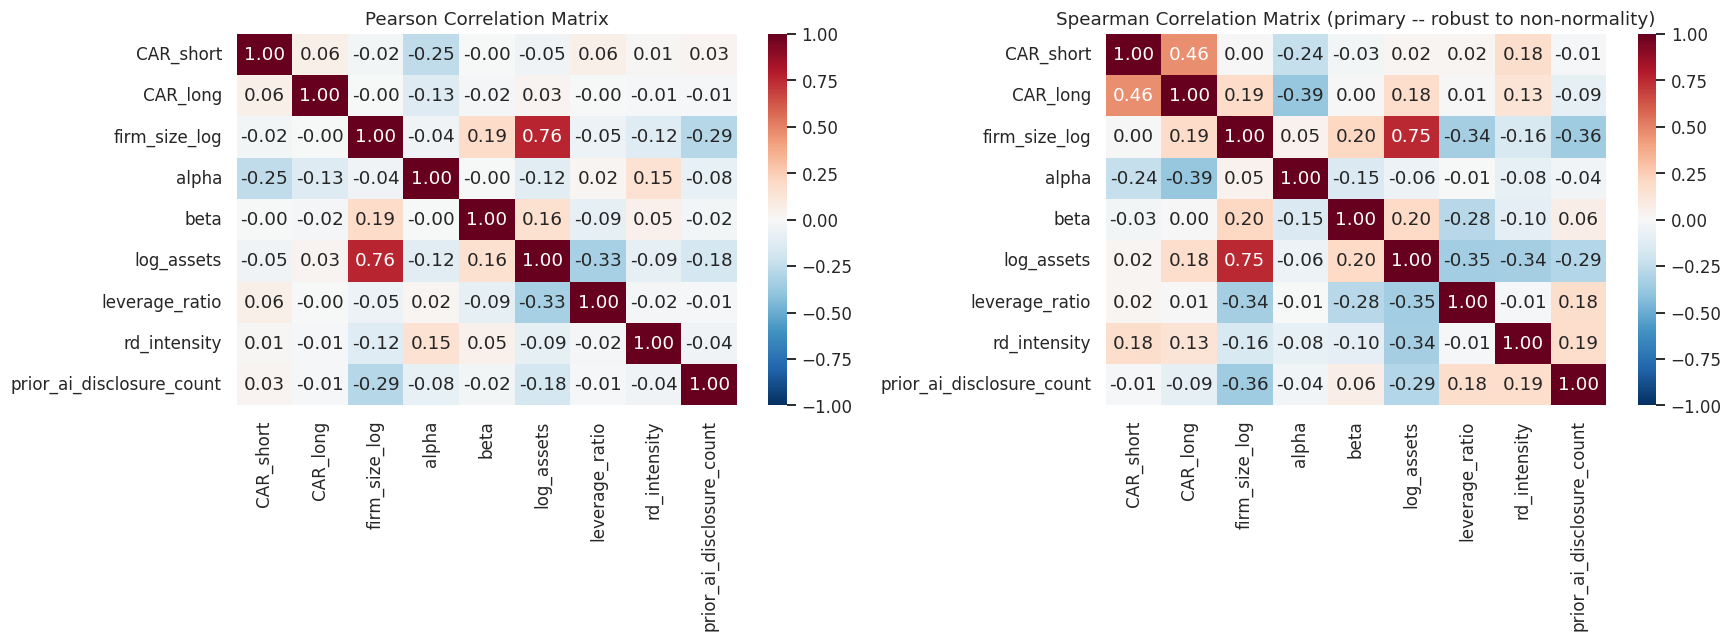

Spearman correlation with CAR_short, ranked:
CAR_long                     0.462721
rd_intensity                 0.175046
leverage_ratio               0.022805
log_assets                   0.020112
firm_size_log                0.001148
prior_ai_disclosure_count   -0.010984
beta                        -0.026131
alpha                       -0.236395
Name: CAR_short, dtype: float64


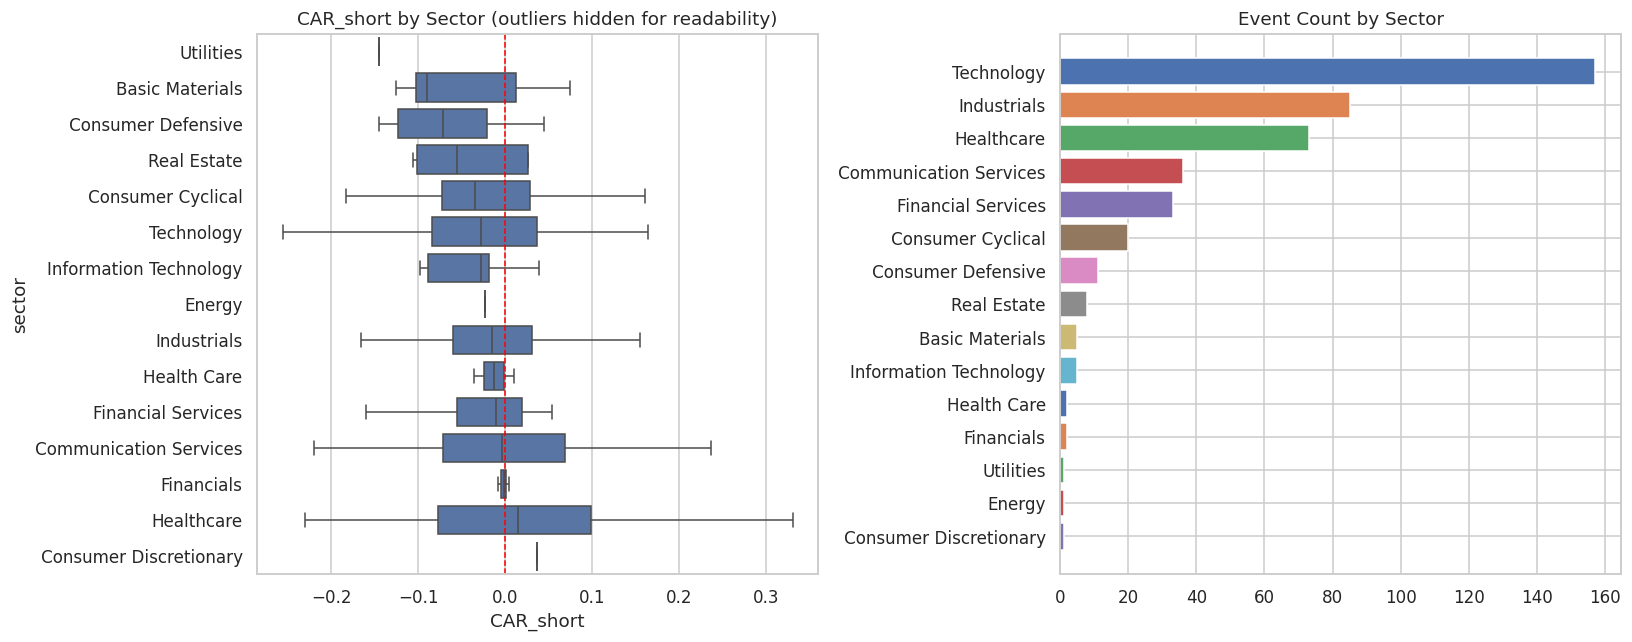


Sector-wise CAR_short summary:
                        count      mean    median       std
sector                                                     
Utilities                   1 -0.145590 -0.145590       NaN
Basic Materials             5 -0.046488 -0.090387  0.085718
Consumer Defensive         11 -0.036667 -0.071617  0.202088
Real Estate                 8 -0.003667 -0.054951  0.256196
Consumer Cyclical          20 -0.029331 -0.035150  0.198567
Technology                157  0.010077 -0.028334  0.356068
Information Technology      5 -0.038875 -0.027351  0.056140
Energy                      1 -0.023376 -0.023376       NaN
Industrials                85  0.008276 -0.015720  0.164296
Health Care                 2 -0.012543 -0.012543  0.032450
Financial Services         33 -0.015443 -0.010357  0.119113
Communication Services     36 -0.006190 -0.003414  0.161935
Financials                  2 -0.001827 -0.001827  0.008772
Healthcare                 73  0.036866  0.014663  0.168663
Consumer

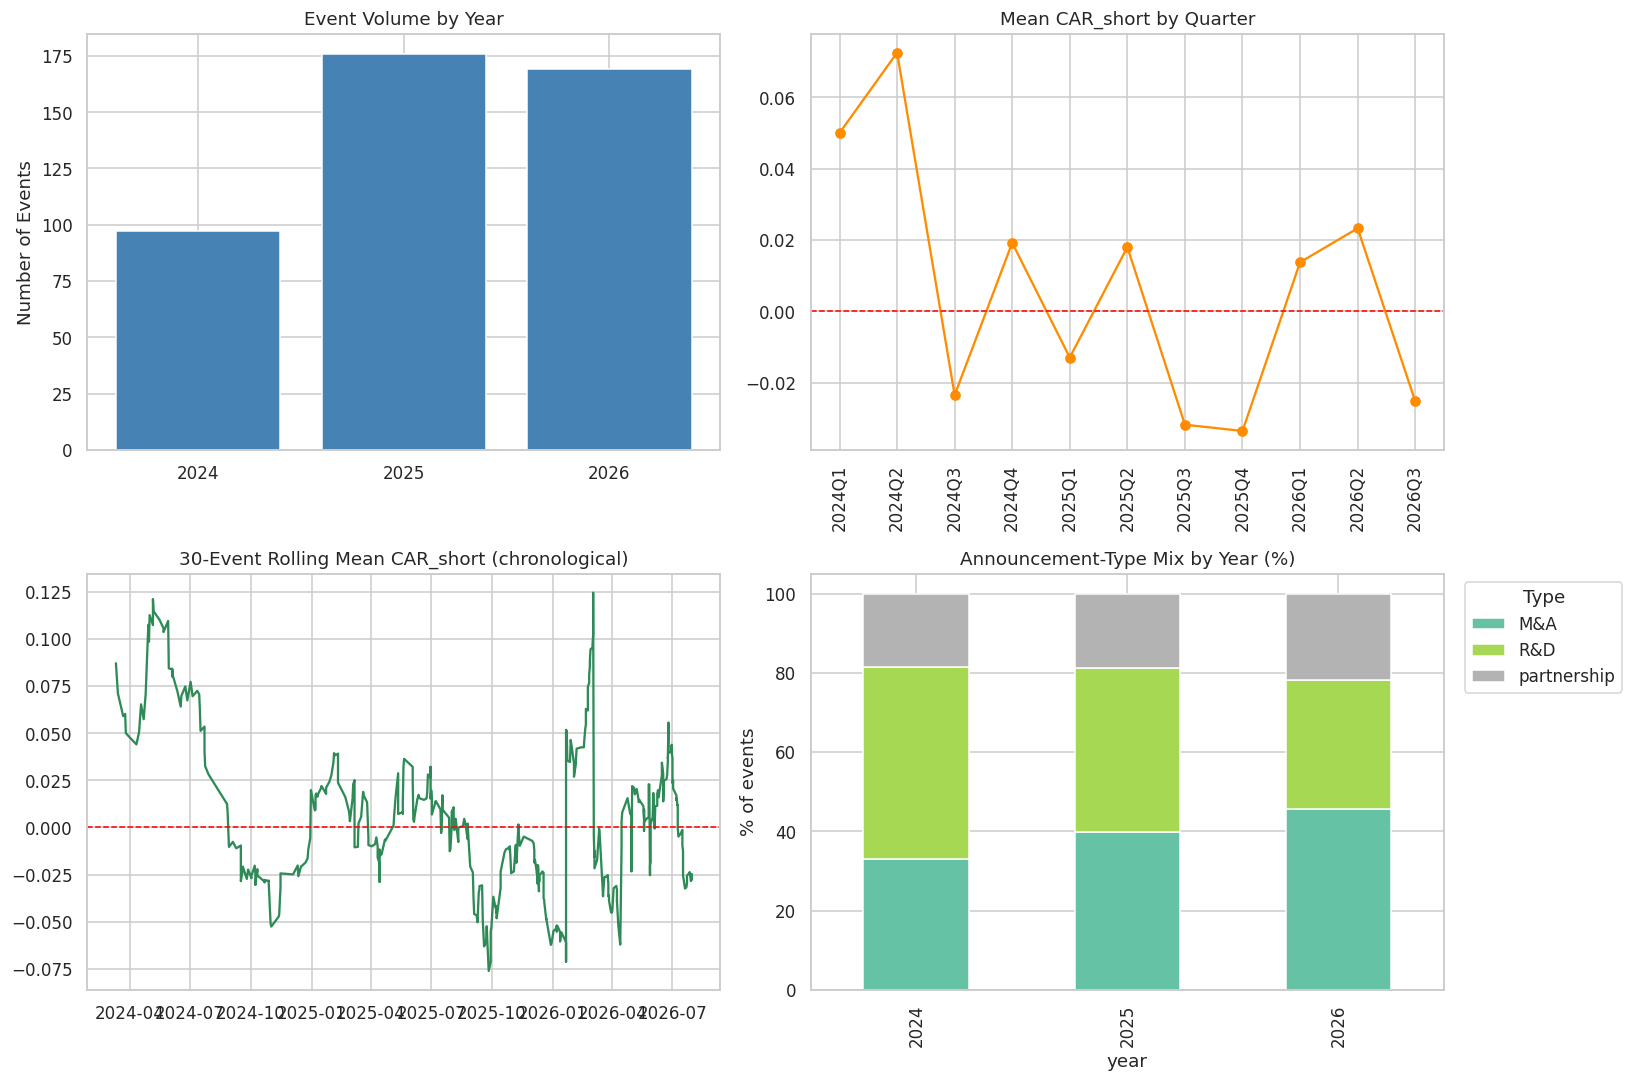

Yearly event volume & CAAR:
        n      caar
year               
2024   97  0.029481
2025  176 -0.017415
2026  169  0.011724


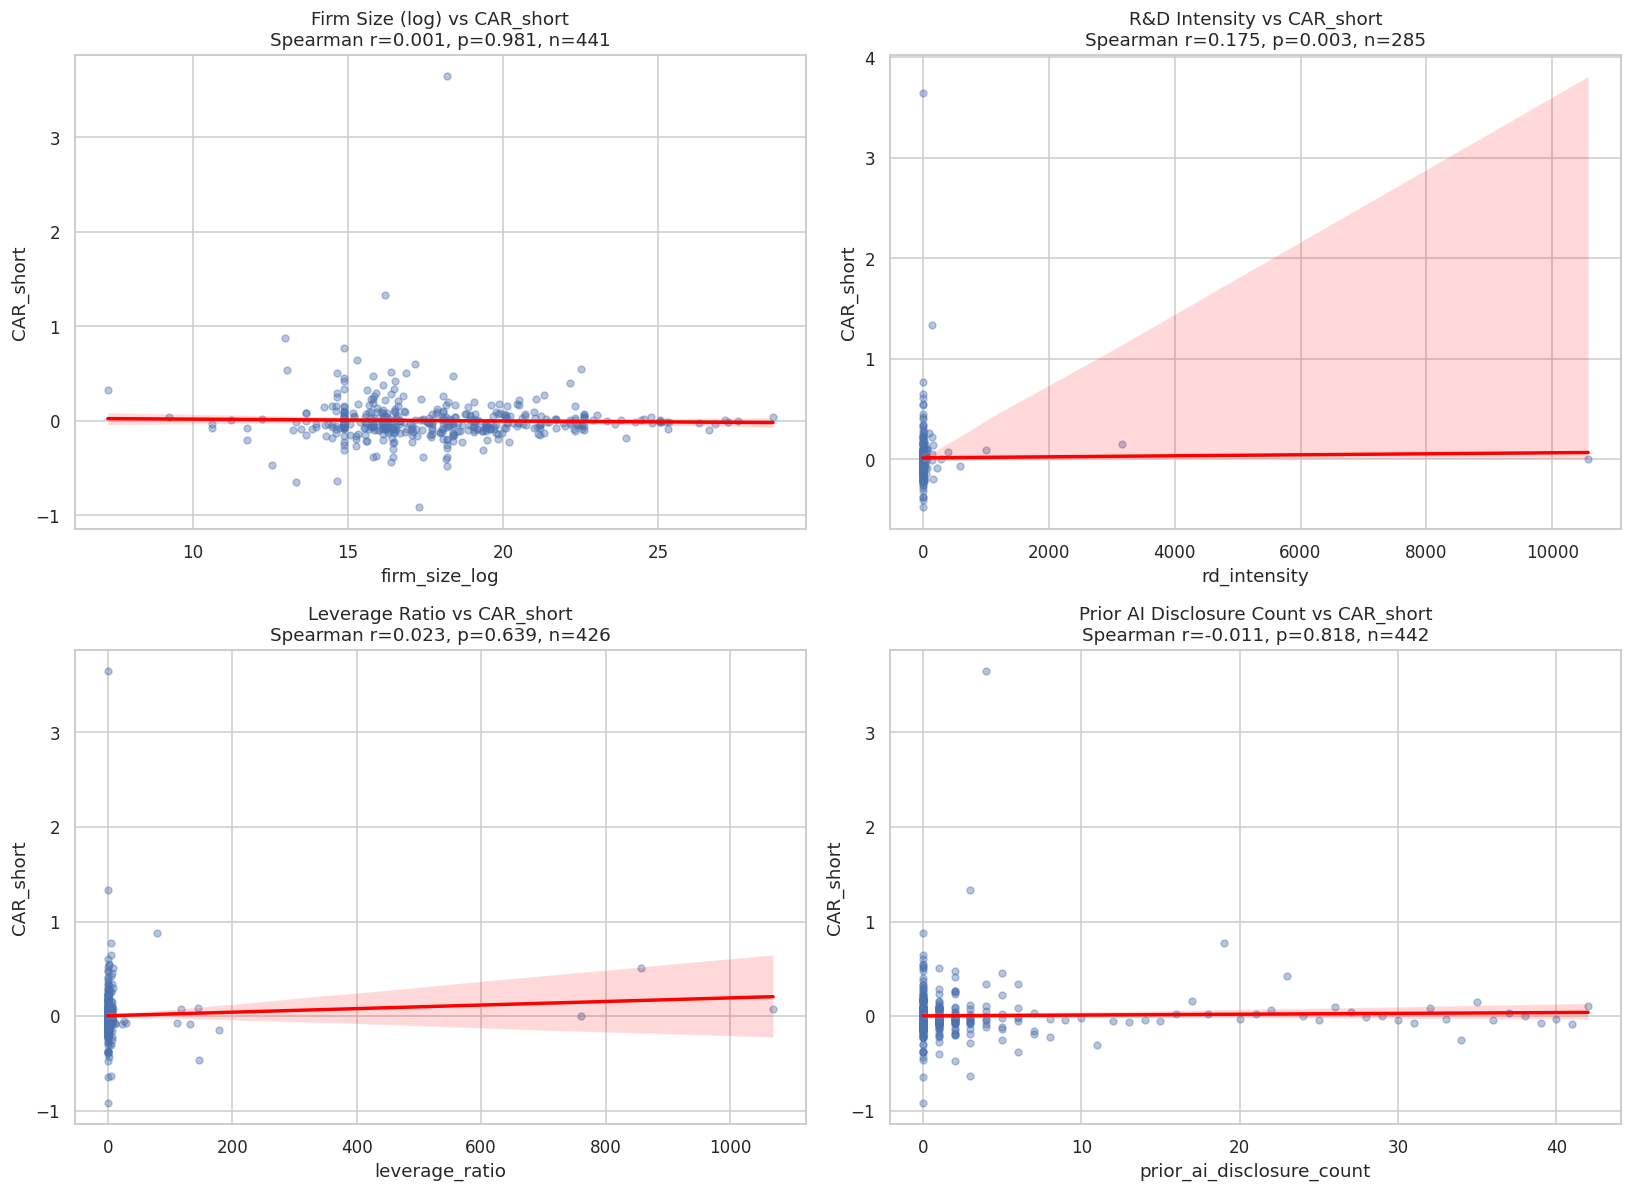

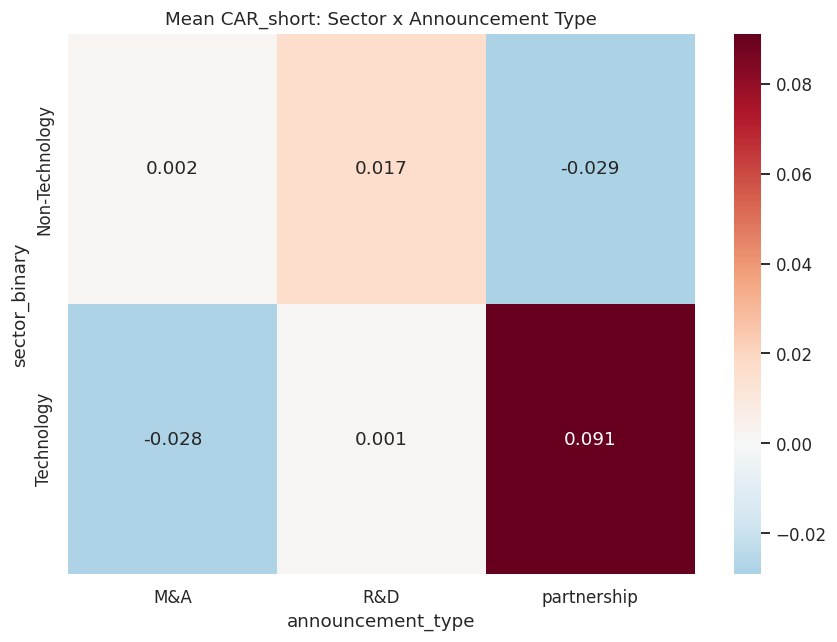


## Automated EDA Insights Summary
*Generated from n=442 events (BSAI excluded, RKTO held out).*

### A. Correlation Analysis
- No numeric predictor shows more than a weak association with CAR_short (max |r| = 0.24, variable: alpha).
- Strongest positive association: **rd_intensity** (Spearman r = 0.175, weak).
- Strongest negative association: **alpha** (Spearman r = -0.236, weak).
- This absence of strong bivariate correlation is *consistent with* RQ3's near-zero R-squared -- no single continuous feature meaningfully explains CAR_short in isolation, which supports rather than contradicts the regression finding.

### B. Sector-Wise Comparison
- Kruskal-Wallis across sectors with n>=5 finds no statistically significant difference in CAR_short (H=11.50, p=0.243).
- Highest median CAR_short: **Healthcare** (1.47%, n=73).
- Lowest median CAR_short: **Basic Materials** (-9.04%, n=5).
- Interpretation should stay descriptive: this sector-level view is exploratory and does not replace RQ4's 

In [1]:
# ============================================================================
# QM 640 Capstone -- Step 5b: Expanded Exploratory Data Analysis
# Addresses mentor feedback: "EDA could be expanded further -- include
# correlation analysis, sector-wise comparisons, trend analysis, feature
# relationships, and temporal patterns."
#
# Exclusion rule matches 06_statistical_tests.ipynb:
#   - BSAI excluded  : degenerate market-model beta (1174.7); illiquid OTC
#                       micro-cap, estimation-window price spans multiple
#                       orders of magnitude -- data-quality issue.
#   - RKTO held out   : ticker symbol changed mid-window (HOTH -> RKTO
#                       effective 2026-05-28); pending price-data alignment
#                       check.
#   - BNAI, MYSE kept : alpha/beta are normal; extreme CAR reflects a real
#                       market reaction, not a data error.
#
# Section F auto-generates a written insights summary from the computed
# statistics below -- it re-derives itself from whatever the data says on
# each rerun rather than containing fixed/hardcoded conclusions.
# ============================================================================

import os
from google.colab import userdata

# --- Cell 1 equivalent: clone/pull the repo ---
GITHUB_USERNAME = "Shanmuganathan75"      # edit if different
REPO_NAME = "QM640-WALSH-CAPSTONE"        # must match the repo URL EXACTLY (hyphens included)
GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')  # set once via Colab Secrets (key icon, left sidebar)

BASE_DIR = f"/content/{REPO_NAME}"
remote_url = f"https://{GITHUB_TOKEN}@github.com/{GITHUB_USERNAME}/{REPO_NAME}.git"

if not os.path.exists(BASE_DIR):
    get_ipython().system('git clone {remote_url} {BASE_DIR}')
else:
    get_ipython().system('git -C {BASE_DIR} pull')

# --- Cell 2 equivalent: install dependencies ---
get_ipython().system('pip install -q pandas numpy scipy matplotlib seaborn')

# --- Cell 3 equivalent: configuration, load data, apply documented exclusions ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

DATA_FILE = os.path.join(BASE_DIR, "data/processed/analysis_dataset.csv")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
FIGDIR = os.path.join(RESULTS_DIR, "figures")
os.makedirs(FIGDIR, exist_ok=True)

ALPHA = 0.05

df = pd.read_csv(DATA_FILE)
df["event_date"] = pd.to_datetime(df["event_date"])
df["year"] = df["event_date"].dt.year
df["quarter"] = df["event_date"].dt.to_period("Q").astype(str)

df_baseline = df.copy()  # unfiltered, kept for reference

EXCLUDED_TICKERS = {
    "BSAI": ("Degenerate market-model beta (1174.7); illiquid OTC micro-cap, "
             "estimation-window price spans multiple orders of magnitude."),
}
HOLDOUT_TICKERS = {
    "RKTO": ("Ticker symbol changed mid-window (HOTH -> RKTO effective "
             "2026-05-28); pending price-data alignment check."),
}

n_before = len(df)
df = df[~df["ticker"].isin(set(EXCLUDED_TICKERS) | set(HOLDOUT_TICKERS))].copy()
print(f"n before exclusions: {n_before}")
print(f"n after exclusions:  {len(df)}\n")


# ============================================================================
# SECTION A -- Correlation Analysis
# ============================================================================
numeric_cols = ["CAR_short", "CAR_long", "firm_size_log", "alpha", "beta",
                 "log_assets", "leverage_ratio", "rd_intensity",
                 "prior_ai_disclosure_count"]
predictor_cols = ["firm_size_log", "alpha", "beta", "log_assets", "leverage_ratio",
                   "rd_intensity", "prior_ai_disclosure_count"]  # excludes CAR_long -- that's another outcome window, not a predictor

corr_pearson = df[numeric_cols].corr(method="pearson")
corr_spearman = df[numeric_cols].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title("Pearson Correlation Matrix")
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title("Spearman Correlation Matrix (primary -- robust to non-normality)")
plt.tight_layout()
plt.savefig(f"{FIGDIR}/fig10_correlation_heatmaps.png", bbox_inches="tight")
plt.show()

print("Spearman correlation with CAR_short, ranked:")
print(corr_spearman["CAR_short"].drop("CAR_short").sort_values(ascending=False))

corr_spearman.to_csv(os.path.join(RESULTS_DIR, "correlation_matrix_spearman.csv"))
corr_pearson.to_csv(os.path.join(RESULTS_DIR, "correlation_matrix_pearson.csv"))


# ============================================================================
# SECTION B -- Sector-Wise Comparison
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sector_order = df.groupby("sector")["CAR_short"].median().sort_values().index
sns.boxplot(data=df, x="CAR_short", y="sector", order=sector_order,
            ax=axes[0], showfliers=False)
axes[0].set_title("CAR_short by Sector (outliers hidden for readability)")
axes[0].axvline(0, color="red", linestyle="--", lw=1)

sector_counts = df["sector"].value_counts()
axes[1].barh(sector_counts.index, sector_counts.values, color=sns.color_palette("deep"))
axes[1].set_title("Event Count by Sector")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(f"{FIGDIR}/fig11_sector_comparison.png", bbox_inches="tight")
plt.show()

sector_summary = (df.groupby("sector")["CAR_short"]
                     .agg(["count", "mean", "median", "std"])
                     .sort_values("median"))
print("\nSector-wise CAR_short summary:")
print(sector_summary)

kw_groups = [g["CAR_short"].dropna().values for _, g in df.groupby("sector") if len(g) >= 5]
h_kw, p_kw = stats.kruskal(*kw_groups)
print(f"\nKruskal-Wallis across sectors (n>=5 groups only): H={h_kw:.3f}, p={p_kw:.4f}")

sector_summary.to_csv(os.path.join(RESULTS_DIR, "sector_summary.csv"))


# ============================================================================
# SECTION C -- Temporal Patterns & Trend Analysis
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

yearly = df.groupby("year").agg(n=("CAR_short", "count"), caar=("CAR_short", "mean"))
axes[0, 0].bar(yearly.index.astype(str), yearly["n"], color="steelblue")
axes[0, 0].set_title("Event Volume by Year")
axes[0, 0].set_ylabel("Number of Events")

quarterly = df.groupby("quarter")["CAR_short"].mean()
axes[0, 1].plot(quarterly.index, quarterly.values, marker="o", color="darkorange")
axes[0, 1].axhline(0, color="red", linestyle="--", lw=1)
axes[0, 1].set_title("Mean CAR_short by Quarter")
axes[0, 1].tick_params(axis="x", rotation=90)

df_sorted = df.sort_values("event_date").reset_index(drop=True)
df_sorted["rolling_caar_30"] = df_sorted["CAR_short"].rolling(window=30, min_periods=10).mean()
axes[1, 0].plot(df_sorted["event_date"], df_sorted["rolling_caar_30"], color="seagreen")
axes[1, 0].axhline(0, color="red", linestyle="--", lw=1)
axes[1, 0].set_title("30-Event Rolling Mean CAR_short (chronological)")

type_by_year = pd.crosstab(df["year"], df["announcement_type"], normalize="index") * 100
type_by_year.plot(kind="bar", stacked=True, ax=axes[1, 1], colormap="Set2")
axes[1, 1].set_title("Announcement-Type Mix by Year (%)")
axes[1, 1].set_ylabel("% of events")
axes[1, 1].legend(title="Type", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig(f"{FIGDIR}/fig12_temporal_trends.png", bbox_inches="tight")
plt.show()

print("Yearly event volume & CAAR:")
print(yearly)
yearly.to_csv(os.path.join(RESULTS_DIR, "yearly_summary.csv"))


# ============================================================================
# SECTION D -- Feature Relationships
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
feat_pairs = [
    ("firm_size_log", "CAR_short", "Firm Size (log) vs CAR_short"),
    ("rd_intensity", "CAR_short", "R&D Intensity vs CAR_short"),
    ("leverage_ratio", "CAR_short", "Leverage Ratio vs CAR_short"),
    ("prior_ai_disclosure_count", "CAR_short", "Prior AI Disclosure Count vs CAR_short"),
]
feature_test_results = []
for ax, (x, y, title) in zip(axes.flat, feat_pairs):
    d = df[[x, y]].dropna()
    sns.regplot(data=d, x=x, y=y, ax=ax, scatter_kws={"alpha": 0.4, "s": 20},
                line_kws={"color": "red"})
    r, p = stats.spearmanr(d[x], d[y])
    ax.set_title(f"{title}\nSpearman r={r:.3f}, p={p:.3f}, n={len(d)}")
    feature_test_results.append((x, r, p))

plt.tight_layout()
plt.savefig(f"{FIGDIR}/fig13_feature_relationships.png", bbox_inches="tight")
plt.show()


# ============================================================================
# SECTION E -- Sector x Announcement-Type Interaction
# ============================================================================
fig, ax = plt.subplots(figsize=(8, 6))
pivot = df.pivot_table(values="CAR_short", index="sector_binary",
                        columns="announcement_type", aggfunc="mean")
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Mean CAR_short: Sector x Announcement Type")
plt.tight_layout()
plt.savefig(f"{FIGDIR}/fig14_sector_type_interaction.png", bbox_inches="tight")
plt.show()


# ============================================================================
# SECTION F -- Automated Insights Summary
# Generates a written narrative directly from the statistics computed above.
# Every claim below is re-derived from the live dataframe on each rerun --
# nothing here is a fixed/hardcoded conclusion.
# ============================================================================
def strength_label(r):
    ar = abs(r)
    if ar < 0.10: return "negligible"
    if ar < 0.30: return "weak"
    if ar < 0.50: return "moderate"
    return "strong"

report_lines = []
report_lines.append("## Automated EDA Insights Summary")
report_lines.append(f"*Generated from n={len(df)} events (BSAI excluded, RKTO held out).*\n")

# --- A. Correlation ---
pred_corr = corr_spearman.loc[predictor_cols, "CAR_short"]
top_pos = pred_corr.sort_values(ascending=False).head(1)
top_neg = pred_corr.sort_values().head(1)
report_lines.append("### A. Correlation Analysis")
report_lines.append(
    f"- No numeric predictor shows more than a {strength_label(pred_corr.abs().max())} "
    f"association with CAR_short (max |r| = {pred_corr.abs().max():.2f}, "
    f"variable: {pred_corr.abs().idxmax()})."
)
report_lines.append(
    f"- Strongest positive association: **{top_pos.index[0]}** "
    f"(Spearman r = {top_pos.values[0]:.3f}, {strength_label(top_pos.values[0])})."
)
report_lines.append(
    f"- Strongest negative association: **{top_neg.index[0]}** "
    f"(Spearman r = {top_neg.values[0]:.3f}, {strength_label(top_neg.values[0])})."
)
report_lines.append(
    "- This absence of strong bivariate correlation is *consistent with* RQ3's "
    "near-zero R-squared -- no single continuous feature meaningfully explains "
    "CAR_short in isolation, which supports rather than contradicts the "
    "regression finding.\n"
)

# --- B. Sector ---
report_lines.append("### B. Sector-Wise Comparison")
sector_summary_5 = sector_summary[sector_summary["count"] >= 5]
best_sector = sector_summary_5["median"].idxmax()
worst_sector = sector_summary_5["median"].idxmin()
sig_text = "a statistically significant" if p_kw < ALPHA else "no statistically significant"
report_lines.append(
    f"- Kruskal-Wallis across sectors with n>=5 finds {sig_text} difference "
    f"in CAR_short (H={h_kw:.2f}, p={p_kw:.3f})."
)
report_lines.append(
    f"- Highest median CAR_short: **{best_sector}** "
    f"({sector_summary_5.loc[best_sector,'median']:.2%}, "
    f"n={int(sector_summary_5.loc[best_sector,'count'])})."
)
report_lines.append(
    f"- Lowest median CAR_short: **{worst_sector}** "
    f"({sector_summary_5.loc[worst_sector,'median']:.2%}, "
    f"n={int(sector_summary_5.loc[worst_sector,'count'])})."
)
report_lines.append(
    "- Interpretation should stay descriptive: this sector-level view is "
    "exploratory and does not replace RQ4's confirmatory tech/non-tech test.\n"
)

# --- C. Temporal ---
report_lines.append("### C. Temporal Patterns")
trend_dir = "increased" if yearly["n"].iloc[-1] > yearly["n"].iloc[0] else "decreased"
caar_years = ", ".join(f"{y}: {v:.2%}" for y, v in yearly["caar"].items())
report_lines.append(
    f"- Event volume by year: {yearly['n'].to_dict()} "
    f"(activity has {trend_dir} over the sample window)."
)
report_lines.append(f"- Mean CAR_short by year: {caar_years}.")
sign_changes = int((np.sign(yearly["caar"]).diff().fillna(0) != 0).sum())
if sign_changes > 0:
    report_lines.append(
        f"- The sign of the average yearly reaction changes {sign_changes} time(s) "
        f"across 2024-2026, indicating the market's response to AI announcements "
        f"has not been stable over the sample window -- worth flagging as a "
        f"limitation on generalizing a single pooled CAAR across the full period."
    )
report_lines.append("")

# --- D. Feature relationships ---
report_lines.append("### D. Feature Relationships")
sig_feats = [t for t in feature_test_results if t[2] < ALPHA]
if sig_feats:
    for f, r, p in sig_feats:
        report_lines.append(
            f"- **{f}** shows a statistically significant association with "
            f"CAR_short (r={r:.3f}, p={p:.3f})."
        )
else:
    report_lines.append(
        "- None of the four examined features (firm size, R&D intensity, "
        "leverage, prior AI disclosure count) show a statistically significant "
        "bivariate association with CAR_short at alpha=.05."
    )
report_lines.append("")

# --- E. Interaction ---
report_lines.append("### E. Sector x Announcement-Type Interaction")
flat = pivot.stack()
max_cell = flat.idxmax()
min_cell = flat.idxmin()
report_lines.append(
    f"- Highest mean CAR_short combination: **{max_cell[1]}** announcements "
    f"from **{max_cell[0]}** firms ({flat[max_cell]:.2%})."
)
report_lines.append(
    f"- Lowest mean CAR_short combination: **{min_cell[1]}** announcements "
    f"from **{min_cell[0]}** firms ({flat[min_cell]:.2%})."
)
report_lines.append(
    "- This pattern is descriptive context for RQ3's formal interaction test, "
    "not a substitute for it (cell sizes are uneven and this view is unadjusted "
    "for firm size as a continuous variable)."
)

eda_report = "\n".join(report_lines)
print("\n" + "="*78)
print(eda_report)

with open(os.path.join(RESULTS_DIR, "eda_summary_report.md"), "w") as f:
    f.write(eda_report)
print(f"\nSaved -> {RESULTS_DIR}/eda_summary_report.md")


# ============================================================================
# Commit and push results back to GitHub
# ============================================================================
get_ipython().system('git -C {BASE_DIR} add "results/figures" "results/correlation_matrix_spearman.csv" "results/correlation_matrix_pearson.csv" "results/sector_summary.csv" "results/yearly_summary.csv" "results/eda_summary_report.md"')
get_ipython().system('git -C {BASE_DIR} commit -m "Step 5b: Expanded EDA + automated insights summary"')
get_ipython().system('git -C {BASE_DIR} push')


In [2]:
!git -C {BASE_DIR} config user.email "Shan_muganathan@yahoo.com"
!git -C {BASE_DIR} config user.name "Shanmuganathan75"

!git -C {BASE_DIR} add "results/figures" "results/correlation_matrix_spearman.csv" "results/correlation_matrix_pearson.csv" "results/sector_summary.csv" "results/yearly_summary.csv" "results/eda_summary_report.md"
!git -C {BASE_DIR} commit -m "Step 5b: Expanded EDA + automated insights summary"
!git -C {BASE_DIR} push

[main 34b18ed] Step 5b: Expanded EDA + automated insights summary
 10 files changed, 67 insertions(+)
 create mode 100644 results/correlation_matrix_pearson.csv
 create mode 100644 results/correlation_matrix_spearman.csv
 create mode 100644 results/eda_summary_report.md
 create mode 100644 results/figures/fig10_correlation_heatmaps.png
 create mode 100644 results/figures/fig11_sector_comparison.png
 create mode 100644 results/figures/fig12_temporal_trends.png
 create mode 100644 results/figures/fig13_feature_relationships.png
 create mode 100644 results/figures/fig14_sector_type_interaction.png
 create mode 100644 results/sector_summary.csv
 create mode 100644 results/yearly_summary.csv
Enumerating objects: 16, done.
Counting objects: 100% (16/16), done.
Delta compression using up to 2 threads
Compressing objects: 100% (14/14), done.
Writing objects: 100% (14/14), 550.42 KiB | 14.48 MiB/s, done.
Total 14 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/Shanmuganathan7